# Connected Component Ablation

This notebook uses `container_logistics` to show the core problem with connected components as prediction units: the units are not comparable.

We only need the simple evidence here: components differ wildly in width (number of objects) and length (time span). The hgv panels below plot five renderable connected components with the same plotting parameters used in `scripts/hgv/example/examples.ipynb`.

In [19]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from relbench.datasets import get_dataset

ROOT = Path.cwd().resolve()
if ROOT.name != "ocel-ocp":
    ROOT = next(p for p in [ROOT, *ROOT.parents] if p.name == "ocel-ocp")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
HGV_ROOT = ROOT / "scripts" / "hgv"
if str(HGV_ROOT) not in sys.path:
    sys.path.insert(0, str(HGV_ROOT))

from data.dataset import register_all_datasets  # noqa: E402
from hgv import make_color_dicts, render  # noqa: E402
from hgv.model import OcelEvent, OcelLog, OcelObject  # noqa: E402
from hgv.transform import connected_components  # noqa: E402

%matplotlib inline

plt.rcParams.update({
    "font.family":           "sans-serif",
    "font.size":             8,
    "legend.fontsize":       7,
    "legend.title_fontsize": 7.5,
    "figure.dpi":            200,
})

# Same figure parameters as scripts/hgv/example/examples.ipynb.
TEXT_W   = 8.27
ROW_H    = 0.2
MARGINS  = 0.3
LEGEND_W = 1.8

_LEG_BASE = dict(
    mode="expand",
    loc="upper left",
    fontsize=7,
    title_fontsize=7.5,
    framealpha=0.9,
    edgecolor="#cccccc",
    handlelength=1.5,
    handletextpad=0.4,
    borderpad=0.6,
)

DATASET_NAME = "container_logistics"
register_all_datasets()

In [20]:
def load_db(name: str):
    """Prefer cached data; fall back to download when the cache is missing."""
    try:
        return get_dataset(name, download=False).get_db()
    except Exception as cached_error:
        print(f"{name}: cached load failed ({type(cached_error).__name__}); retrying with download=True")
        return get_dataset(name, download=True).get_db()


def db_to_hgv_log(db) -> OcelLog:
    event_df = db.table_dict["event"].df.copy()
    object_df = db.table_dict["object"].df.copy()
    e2o_df = db.table_dict["e2o"].df.copy()

    event_to_objects = e2o_df.groupby("event_id")["object_id"].apply(list).to_dict()
    objects = [
        OcelObject(id=str(row.object_id), type=str(row.type))
        for row in object_df.itertuples(index=False)
    ]
    events = [
        OcelEvent(
            id=str(row.event_id),
            type=str(row.type),
            time=row.time.to_pydatetime() if hasattr(row.time, "to_pydatetime") else row.time,
            object_ids=[str(oid) for oid in event_to_objects.get(row.event_id, [])],
        )
        for row in event_df.itertuples(index=False)
    ]
    events.sort(key=lambda event: event.time)

    return OcelLog(
        object_types=[str(value) for value in object_df["type"].dropna().unique()],
        event_types=[str(value) for value in event_df["type"].dropna().unique()],
        objects=objects,
        events=events,
    )


def component_frame(components: list[OcelLog]) -> pd.DataFrame:
    rows = []
    for component_id, component in enumerate(components):
        if component.events:
            start = min(event.time for event in component.events)
            end = max(event.time for event in component.events)
            span_hours = (end - start).total_seconds() / 3600
        else:
            start = pd.NaT
            end = pd.NaT
            span_hours = 0
        object_counts = Counter(obj.type for obj in component.objects)
        rows.append({
            "component_id": component_id,
            "objects": len(component.objects),
            "events": len(component.events),
            "object_types": len(object_counts),
            "start": start,
            "end": end,
            "span_hours": span_hours,
            "span_days": span_hours / 24,
            "object_type_mix": dict(object_counts),
        })
    return pd.DataFrame(rows).sort_values("objects", ascending=False)


def make_component_fig(component: OcelLog, title: str, *, time_range):
    panel_h = max(len(component.objects) * ROW_H + MARGINS, 1.0)
    fig = plt.figure(figsize=(TEXT_W, panel_h))
    ax = fig.add_subplot(111)
    render(
        component,
        ax=ax,
        row_height=ROW_H,
        obj_color=obj_color,
        evt_color=evt_color,
        time_range=time_range,
    )
    fig.suptitle(title, y=1.02)
    plt.show()
    return fig

In [21]:
db = load_db(DATASET_NAME)
log = db_to_hgv_log(db)
components = connected_components(log)
components = [component for component in components if component.objects or component.events]
stats = component_frame(components)

_all_times = [event.time for event in log.events]
GLOBAL_TMIN = min(_all_times)
GLOBAL_TMAX = max(_all_times)
TIME_RANGE = (GLOBAL_TMIN, GLOBAL_TMAX)

obj_color, evt_color = make_color_dicts(log)

print(f"{DATASET_NAME}: {len(log.objects)} objects, {len(log.events)} events")
print(f"Connected components: {len(components)}")
print(f"Global span: {GLOBAL_TMIN} - {GLOBAL_TMAX}")
stats[["component_id", "objects", "events", "object_types", "span_days", "start", "end", "object_type_mix"]]

Loading Database object from /root/scratch/relbench/container_logistics/db...
Done in 0.12 seconds.
container_logistics: 11647 objects, 29605 events
Connected components: 7
Global span: 2023-05-22 11:54:42 - 2024-05-31 23:52:43


,component_id,objects,events,object_types,span_days,start,end,object_type_mix
0,0,11632,29593,7,375.498623,2023-05-22 11:54:42,2024-05-31 23:52:43,"{'Customer Order': 491, 'Transport Document': ..."
4,4,7,4,4,0.886956,2024-05-30 15:46:14,2024-05-31 13:03:27,"{'Customer Order': 1, 'Transport Document': 1,..."
1,1,4,4,4,8.857292,2024-05-22 16:00:06,2024-05-31 12:34:36,"{'Customer Order': 1, 'Transport Document': 1,..."
2,2,1,1,1,0.000000,2024-05-28 09:18:46,2024-05-28 09:18:46,{'Customer Order': 1}
3,3,1,1,1,0.000000,2024-05-30 09:40:46,2024-05-30 09:40:46,{'Customer Order': 1}
5,5,1,1,1,0.000000,2024-05-31 11:48:59,2024-05-31 11:48:59,{'Customer Order': 1}
6,6,1,1,1,0.000000,2024-05-31 22:34:37,2024-05-31 22:34:37,{'Handling Unit': 1}


## Width And Length

The first connected component is the point: it absorbs almost the entire log. Rendering it with the hgv example's `ROW_H = 0.2` would require a figure thousands of inches tall, so it is summarized in the table/bar chart rather than plotted as a panel.

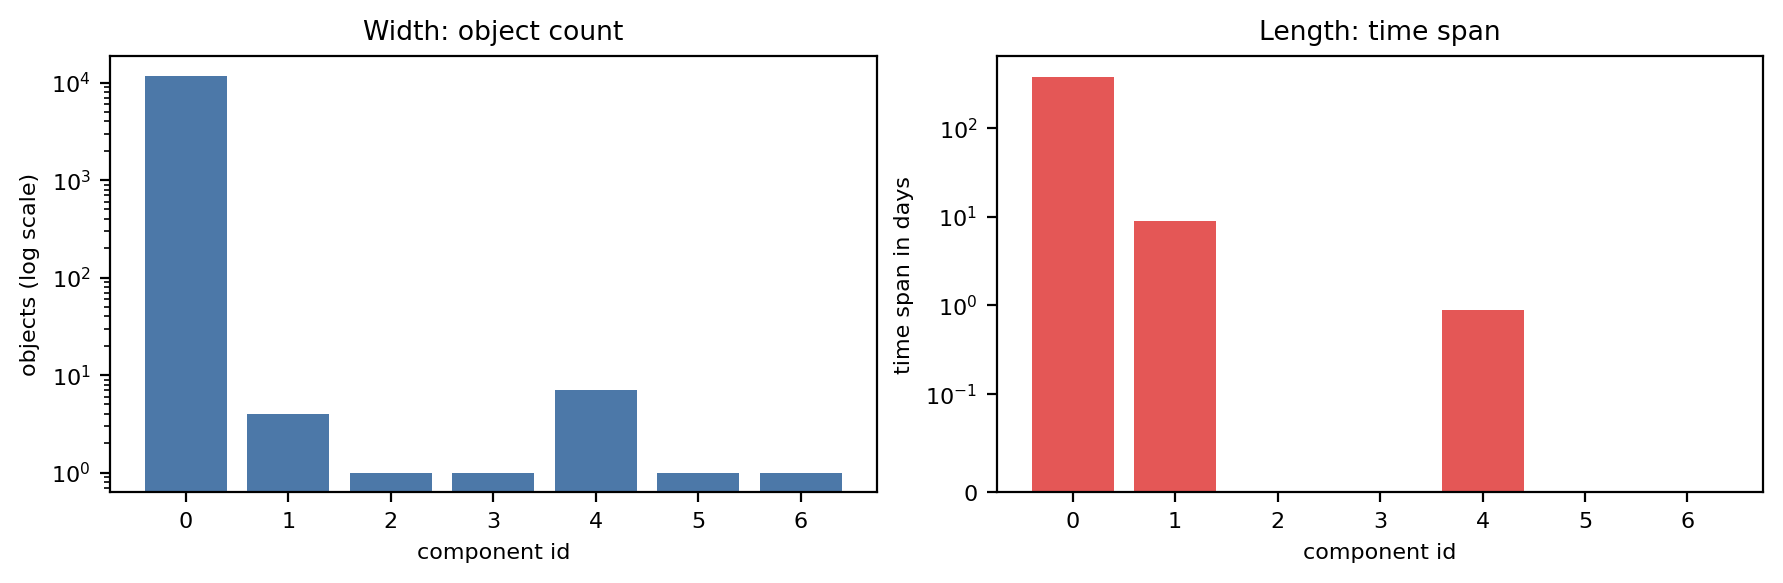

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(8.8, 2.8), constrained_layout=True)
plot_stats = stats.sort_values("component_id")

axes[0].bar(plot_stats["component_id"].astype(str), plot_stats["objects"], color="#4c78a8")
axes[0].set_yscale("log")
axes[0].set_xlabel("component id")
axes[0].set_ylabel("objects (log scale)")
axes[0].set_title("Width: object count")

axes[1].bar(plot_stats["component_id"].astype(str), plot_stats["span_days"], color="#e45756")
axes[1].set_yscale("symlog", linthresh=0.1)
axes[1].set_xlabel("component id")
axes[1].set_ylabel("time span in days")
axes[1].set_title("Length: time span")

plt.show()

In [23]:
largest = stats.iloc[0]
print(
    f"Largest component {int(largest.component_id)}: "
    f"{int(largest.objects)}/{len(log.objects)} objects ({largest.objects / len(log.objects):.1%}), "
    f"{int(largest.events)}/{len(log.events)} events ({largest.events / len(log.events):.1%}), "
    f"span {largest.span_days:.1f} days."
)
print(
    "This is not a comparable prediction unit; it is effectively the whole log, "
    "while the remaining components are tiny residual units."
)

Largest component 0: 11632/11647 objects (99.9%), 29593/29605 events (100.0%), span 375.5 days.
This is not a comparable prediction unit; it is effectively the whole log, while the remaining components are tiny residual units.


## Five HGV Component Panels

Below are five renderable connected components, using the same hgv rendering constants as the example notebook and a shared full-log time range. The rows are the width of the unit; the horizontal axis is the length of its observed lifetime.

In [24]:
RENDER_OBJECT_LIMIT = 25
selected_component_ids = (
    stats[stats["objects"] <= RENDER_OBJECT_LIMIT]
    .sort_values(["objects", "span_hours"], ascending=[False, False])
    .head(5)["component_id"]
    .astype(int)
    .tolist()
)
selected_component_ids

[4, 1, 2, 3, 5]

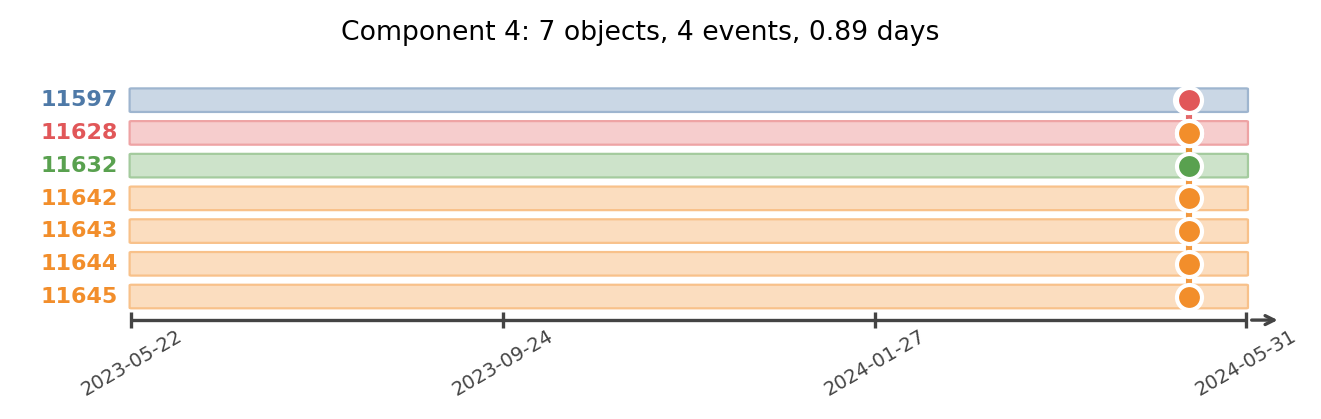

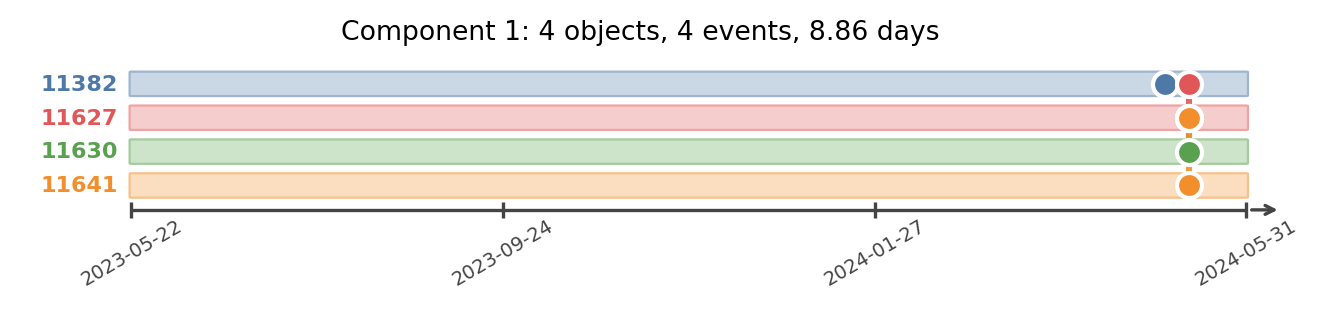

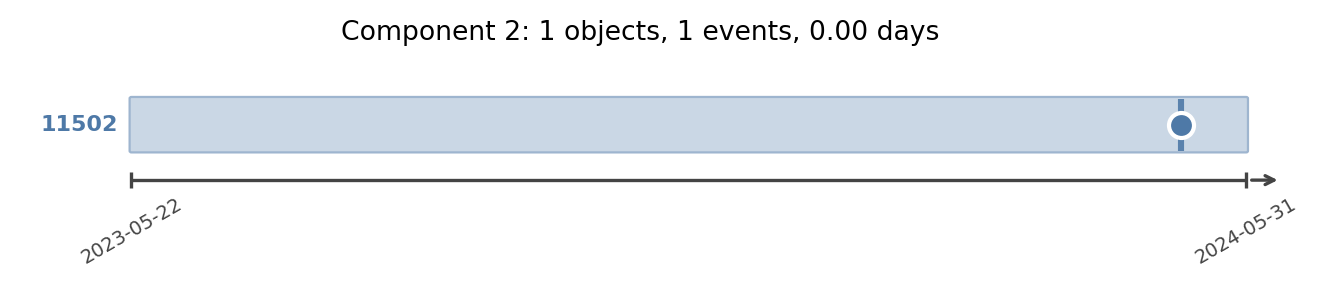

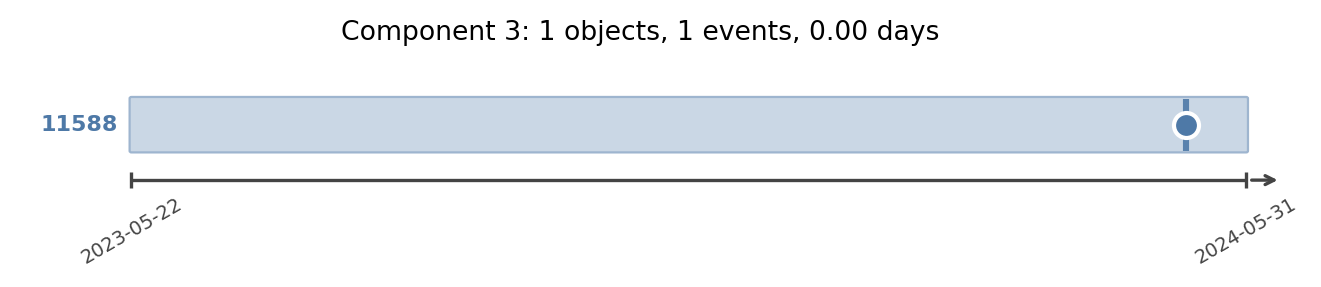

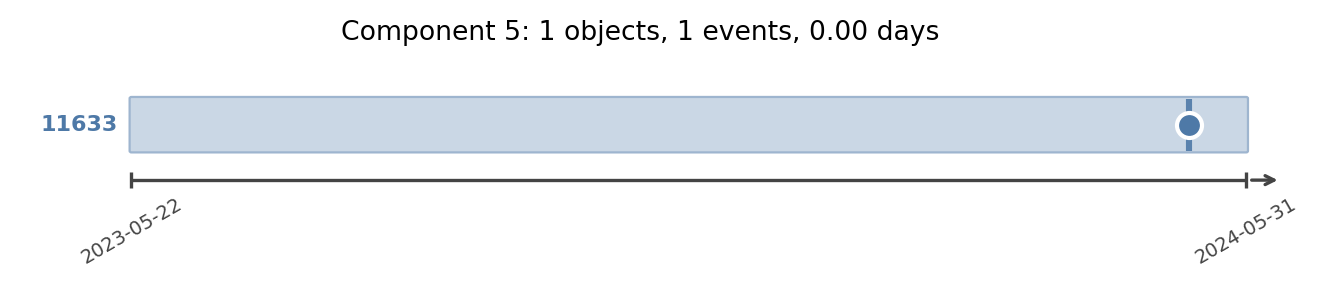

In [25]:
for component_id in selected_component_ids:
    row = stats[stats["component_id"] == component_id].iloc[0]
    title = (
        f"Component {component_id}: {int(row.objects)} objects, "
        f"{int(row.events)} events, {row.span_days:.2f} days"
    )
    make_component_fig(components[component_id], title, time_range=TIME_RANGE)

## Takeaway

Connected components are not good prediction units here. In `container_logistics`, one component is essentially the whole log, while the others range from short four-event traces to singleton events. That makes component-level prediction a comparison between incompatible units rather than a clean inductive learning problem.